# 02 — Resume Classifier (supervised)
Clean text → TF-IDF → Logistic Regression. Evaluate with confusion matrix + F1.

## Objective

The objective of this notebook is to build a machine learning model that predicts the job category of a resume based on its textual content.

The workflow includes:

- Loading the processed resume dataset
- Preparing input features and labels
- Converting resume text into numerical features using TF-IDF
- Splitting the dataset into training and testing sets
- Training a classification model
- Evaluating model performance
- Saving the trained model for deployment

In [1]:
# ============================================================
# Import Required Libraries
# ============================================================

import pandas as pd
import numpy as np

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

import joblib

In [2]:
# ============================================================
# Load Resume Dataset
# ============================================================

PROJECT_ROOT = Path("..")
PROCESSED_DATA = PROJECT_ROOT / "data" / "processed"

resumes_df = pd.read_csv(PROCESSED_DATA / "resumes_clean.csv")

print("Resume dataset loaded successfully!")

display(resumes_df.head())

Resume dataset loaded successfully!


,Category,text
0,Data Science,skills programming languages python pandas num...
1,Data Science,education details may 2013 to may 2017 b.e uit...
2,Data Science,areas of interest deep learning control system...
3,Data Science,skills r python sap hana tableau sap hana sql ...
4,Data Science,education details mca ymcaust faridabad haryan...


In [3]:
# ============================================================
# Dataset Overview
# ============================================================

print(f"Number of Resumes   : {len(resumes_df)}")
print(f"Number of Columns   : {resumes_df.shape[1]}")
print(f"Unique Categories   : {resumes_df['Category'].nunique()}")

display(resumes_df.head())

Number of Resumes   : 962
Number of Columns   : 2
Unique Categories   : 25


,Category,text
0,Data Science,skills programming languages python pandas num...
1,Data Science,education details may 2013 to may 2017 b.e uit...
2,Data Science,areas of interest deep learning control system...
3,Data Science,skills r python sap hana tableau sap hana sql ...
4,Data Science,education details mca ymcaust faridabad haryan...


In [4]:
# ============================================================
# Define Features and Target
# ============================================================

# Input Feature
X = resumes_df["text"]

# Target Variable
y = resumes_df["Category"]

print("Feature Shape :", X.shape)
print("Target Shape  :", y.shape)

Feature Shape : (962,)
Target Shape  : (962,)


In [5]:
# ============================================================
# Label Encoding
# ============================================================

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("First 10 Encoded Labels:")
print(y_encoded[:10])

First 10 Encoded Labels:
[6 6 6 6 6 6 6 6 6 6]


In [6]:
# ============================================================
# Category Mapping
# ============================================================

category_mapping = pd.DataFrame({
    "Category": label_encoder.classes_,
    "Encoded Label": range(len(label_encoder.classes_))
})

display(category_mapping)

,Category,Encoded Label
0,Advocate,0
1,Arts,1
2,Automation Testing,2
3,Blockchain,3
4,Business Analyst,4
5,Civil Engineer,5
6,Data Science,6
7,Database,7
8,DevOps Engineer,8
9,DotNet Developer,9


In [7]:
# ============================================================
# Train-Test Split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Training Samples :", len(X_train))
print("Testing Samples  :", len(X_test))

Training Samples : 769
Testing Samples  : 193


## Observation

- The resume dataset contains 962 records across 25 categories.
- The dataset has been divided into training (80%) and testing (20%) subsets.
- Stratified sampling preserves the class distribution in both subsets.
- The data is now ready for feature extraction using TF-IDF.

In [8]:
# ============================================================
# TF-IDF Vectorization
# ============================================================

tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=5000
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training Feature Matrix :", X_train_tfidf.shape)
print("Testing Feature Matrix  :", X_test_tfidf.shape)

Training Feature Matrix : (769, 5000)
Testing Feature Matrix  : (193, 5000)


In [9]:
# ============================================================
# Train Logistic Regression Model
# ============================================================

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train_tfidf, y_train)

print("Model trained successfully!")

Model trained successfully!


In [10]:
# ============================================================
# Make Predictions
# ============================================================

y_pred = model.predict(X_test_tfidf)

print("Predictions generated successfully!")

Predictions generated successfully!


In [11]:
# ============================================================
# Model Accuracy
# ============================================================

accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy : {accuracy:.4f}")
print(f"Accuracy (%)   : {accuracy * 100:.2f}%")

Model Accuracy : 0.9948
Accuracy (%)   : 99.48%


In [12]:
# ============================================================
# Classification Report
# ============================================================

print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
))

                           precision    recall  f1-score   support

                 Advocate       1.00      1.00      1.00         4
                     Arts       1.00      1.00      1.00         7
       Automation Testing       0.83      1.00      0.91         5
               Blockchain       1.00      1.00      1.00         8
         Business Analyst       1.00      1.00      1.00         6
           Civil Engineer       1.00      1.00      1.00         5
             Data Science       1.00      1.00      1.00         8
                 Database       1.00      1.00      1.00         7
          DevOps Engineer       1.00      0.91      0.95        11
         DotNet Developer       1.00      1.00      1.00         5
            ETL Developer       1.00      1.00      1.00         8
   Electrical Engineering       1.00      1.00      1.00         6
                       HR       1.00      1.00      1.00         9
                   Hadoop       1.00      1.00      1.00     

<Figure size 1400x1400 with 0 Axes>

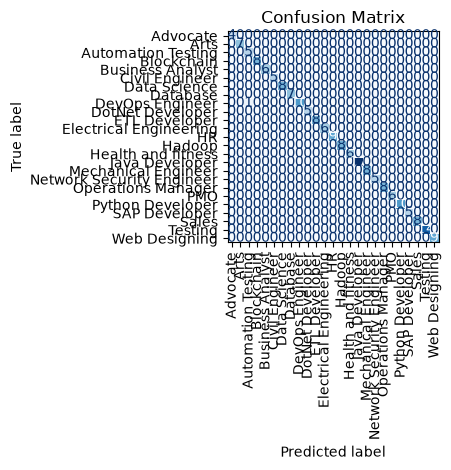

In [13]:
# ============================================================
# Confusion Matrix
# ============================================================

plt.figure(figsize=(14, 14))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=label_encoder.classes_,
    xticks_rotation=90,
    cmap="Blues",
    colorbar=False
)

plt.title("Confusion Matrix")

plt.tight_layout()

plt.show()

In [14]:
# ============================================================
# Save Model and Preprocessing Objects
# ============================================================

PROJECT_ROOT = Path("..")
MODEL_DIR = PROJECT_ROOT / "models"

MODEL_DIR.mkdir(exist_ok=True)

joblib.dump(model, MODEL_DIR / "resume_classifier.pkl")
joblib.dump(tfidf, MODEL_DIR / "tfidf_vectorizer.pkl")
joblib.dump(label_encoder, MODEL_DIR / "label_encoder.pkl")

print("Model and preprocessing objects saved successfully!")

Model and preprocessing objects saved successfully!


# Conclusion

The resume classification model was successfully developed using TF-IDF feature extraction and Logistic Regression.

### Results

- Resume dataset successfully loaded.
- Labels encoded using LabelEncoder.
- Dataset split into training and testing sets.
- TF-IDF converted textual resumes into numerical feature vectors.
- Logistic Regression achieved an accuracy of **99.48%** on the test dataset.
- The trained model, TF-IDF vectorizer, and Label Encoder were saved for deployment.

The trained classifier is now ready to be integrated into the SmartHire application.